# Week 6-Decision Trees and Random Forests
## Integrated Capstone Project: Predicting Chronic Disease Risk Using Lifestyle and Health Indicators

**Student:** Ranjana Kumari  
**Course:** Module C — Data Science Capstone  
**Week:** 6 of 6 - Tree-Based Ensemble Methods

---

## Research Question

> *Can tree-based ensemble methods—specifically Random Forests-outperform logistic regression and SVM for chronic disease classification, and what do feature importance scores reveal about which lifestyle and health variables most consistently predict disease risk across three different chronic conditions?*

---

## Connection to Previous Weeks and Final Synthesis

Week 6 is the final modeling week and serves as both a new analysis and a synthesis of the entire capstone project.

- **Week 1–2:** Linear regression explained only a limited portion of variation in diabetes status (R² = 0.1629), suggesting that disease risk is influenced by complex nonlinear relationships.
- **Week 3:** Forward selection and PLSR identified a small set of influential predictors. Random Forest feature importance can be used to validate these findings.
- **Week 4:** Logistic regression achieved F1-scores of 0.3822 (Diabetes), 0.9649 (Obesity), and 0.8333 (Heart Disease), providing a baseline for classification performance.
- **Week 5:** SVM results showed that nonlinear decision boundaries improved performance for Diabetes and Heart Disease, while Obesity remained largely linearly separable.

Random Forests may further improve performance because they capture nonlinear interactions and threshold effects through recursive feature splitting. In addition, feature importance scores provide insight into which lifestyle and health indicators most consistently predict chronic disease risk across datasets.

**Why Random Forests for this problem:** Decision trees identify patterns by splitting features at important thresholds, while Random Forests combine many trees to reduce overfitting and improve generalization. This makes them well suited for healthcare datasets that contain complex relationships among lifestyle, demographic, and clinical risk factors.

## Deep-Dive Topic Declaration

Week 6 is my secoand designated deep-dive topic. This notebook contains full depth of analysis across all five rubric sub-questions for each dataset.

---

## Datasets Used

| # | Dataset | Role | Rows | Target |
|---|---------|------|------|--------|
| 1 | **CDC Diabetes Health Indicators** | Primary | ~230k | Diabetes_012 (3-class) |
| 2 | **Obesity Level Estimation** | Supporting | 2,087 | NObeyesdad (7-class) |
| 3 | **Heart Disease Predictions** | Supporting | 303 | target (binary) |

---
## Section 1: Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score, precision_score,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

COLORS = {
    'diabetes': '#1D9E75',
    'obesity':  '#7F77DD',
    'heart':    '#D85A30',
    'tree':     '#EF9F27',
    'forest':   '#1D9E75',
    'lr':       '#B4B2A9',
}
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('All libraries loaded.')
print('Week 6: Decision Trees and Random Forests — Final Modeling Week')

All libraries loaded.
Week 6: Decision Trees and Random Forests — Final Modeling Week


---
## Section 2: Data Loading and Preparation

**Note on scaling:** Unlike SVM and logistic regression, decision trees and random forests are scale-invariant — they split on feature thresholds and do not use distance or gradient calculations. Scaling is therefore not required. However, StandardScaler is applied for consistency with previous weeks and to allow fair comparison of feature importance values.

In [2]:
# Dataset 1: CDC Diabetes
file_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/diabetes_012_health_indicators_BRFSS2015.csv"

df1 = pd.read_csv(file_path).drop_duplicates()

ds1_features = ['BMI', 'Age', 'HighBP', 'HighChol', 'PhysActivity',
                'Smoker', 'GenHlth', 'Income', 'Education', 'DiffWalk', 'PhysHlth']

X1 = df1[ds1_features].copy()
y1 = df1['Diabetes_012'].copy()

X1_tr, X1_te, y1_tr, y1_te = train_test_split(
    X1, y1, test_size=0.20, random_state=42, stratify=y1
)

print('=== Dataset 1: CDC Diabetes ===')
print(f'Shape: {df1.shape}')
print(f'Train: {X1_tr.shape[0]:,} | Test: {X1_te.shape[0]:,}')
print('Class distribution:')
for cls, label in [(0, 'No Diabetes'), (1, 'Prediabetes'), (2, 'Diabetes')]:
    n = (y1 == cls).sum()
    print(f'  {label}: {n:,} ({n/len(y1)*100:.1f}%)')


# Dataset 2: Obesity
obesity_file = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/Obesity.csv"

df2 = pd.read_csv(obesity_file).drop_duplicates()
df2.columns = df2.columns.str.strip()

le = LabelEncoder()
df2_enc = df2.copy()

for col in df2_enc.select_dtypes(include='object').columns:
    if col != 'NObeyesdad':
        df2_enc[col] = le.fit_transform(df2_enc[col].astype(str))

df2_enc['target_encoded'] = le.fit_transform(df2['NObeyesdad'])

ds2_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'FAF', 'TUE']
ds2_features = [f for f in ds2_features if f in df2_enc.columns]

X2 = df2_enc[ds2_features].copy()
X2['BMI_calc'] = X2['Weight'] / (X2['Height'] ** 2)
y2 = df2_enc['target_encoded'].copy()

X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, y2, test_size=0.20, random_state=42, stratify=y2
)

ds2_feature_names = list(X2.columns)

print(f'\nDataset 2 (Obesity) — Train: {X2_tr.shape[0]} | Test: {X2_te.shape[0]}')


# Dataset 3: Heart Disease
heart_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/heart.csv-2.xls"

df3 = pd.read_csv(heart_path)

ds3_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak',
                'sex', 'exang', 'cp', 'ca', 'thal']

X3 = df3[ds3_features].copy()
y3 = df3['target'].copy()

X3_tr, X3_te, y3_tr, y3_te = train_test_split(
    X3, y3, test_size=0.20, random_state=42, stratify=y3
)

print(f'Dataset 3 (Heart Disease) — Train: {X3_tr.shape[0]} | Test: {X3_te.shape[0]}')

=== Dataset 1: CDC Diabetes ===
Shape: (229781, 22)
Train: 183,824 | Test: 45,957
Class distribution:
  No Diabetes: 190,055 (82.7%)
  Prediabetes: 4,629 (2.0%)
  Diabetes: 35,097 (15.3%)

Dataset 2 (Obesity) — Train: 1669 | Test: 418
Dataset 3 (Heart Disease) — Train: 242 | Test: 61


In [ ]:
# Decision Tree: Demonstrate Overfitting vs Controlled Depth ───────────────
# This section shows WHY random forests are needed by demonstrating
# how a single unrestricted tree overfits vs a depth-limited tree

print('=== Decision Tree: Overfitting Demonstration (Dataset 1 — CDC Diabetes) ===')
print('Testing different max_depth values to show the bias-variance tradeoff')
print()

depths = [None, 2, 4, 6, 8, 10, 15]
dt_results = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X1_tr, y1_tr)
    train_f1 = f1_score(y1_tr, dt.predict(X1_tr), average='macro')
    test_f1  = f1_score(y1_te, dt.predict(X1_te), average='macro')
    gap = train_f1 - test_f1
    dt_results.append({
        'max_depth': str(depth) if depth else 'None (full)',
        'train_f1': round(train_f1, 4),
        'test_f1':  round(test_f1,  4),
        'gap':      round(gap, 4)
    })
    print(f'max_depth={str(depth):<12} | Train F1={train_f1:.4f} | Test F1={test_f1:.4f} | Gap={gap:.4f}')

print()
print('Key observation: max_depth=None (unrestricted tree) achieves Train F1 ≈ 1.0')
print('but much lower Test F1 — this is textbook overfitting.')
print('Random forests solve this by averaging many trees, each with limited depth.')

# Best single tree depth
best_dt_row = max(dt_results, key=lambda x: x['test_f1'])
print(f'\nBest single tree: max_depth={best_dt_row["max_depth"]} | Test F1={best_dt_row["test_f1"]}')
print('We will compare this to Random Forest performance below.')

=== Decision Tree: Overfitting Demonstration (Dataset 1 — CDC Diabetes) ===
Testing different max_depth values to show the bias-variance tradeoff

max_depth=None         | Train F1=0.9144 | Test F1=0.3910 | Gap=0.5234
max_depth=2            | Train F1=0.3018 | Test F1=0.3018 | Gap=-0.0000
max_depth=4            | Train F1=0.3946 | Test F1=0.3982 | Gap=-0.0036
max_depth=6            | Train F1=0.3567 | Test F1=0.3584 | Gap=-0.0017
max_depth=8            | Train F1=0.3857 | Test F1=0.3868 | Gap=-0.0011
max_depth=10           | Train F1=0.4051 | Test F1=0.3936 | Gap=0.0115
max_depth=15           | Train F1=0.5763 | Test F1=0.4005 | Gap=0.1758

Key observation: max_depth=None (unrestricted tree) achieves Train F1 ≈ 1.0
but much lower Test F1 — this is textbook overfitting.
Random forests solve this by averaging many trees, each with limited depth.

Best single tree: max_depth=15 | Test F1=0.4005
We will compare this to Random Forest performance below.


### Decision Tree Overfitting Analysis

The decision tree results clearly demonstrate the bias-variance tradeoff. The unrestricted tree (max_depth=None) achieved a very high training F1-score (0.9144) but a much lower test F1-score (0.3910), resulting in a large train-test gap of 0.5234. This indicates severe overfitting, where the model memorized patterns in the training data but failed to generalize to unseen observations.

As tree depth increased from 2 to 15, training performance improved steadily. However, test performance improved only slightly, suggesting that additional model complexity provided limited predictive benefit. The best-performing single tree achieved a test F1-score of 0.4005 at max_depth=15, which was only marginally better than shallower trees.

One interesting finding is that the best single decision tree (F1 = 0.4005) performed similarly to the best Week 5 SVM model (F1 = 0.4010). This suggests that the CDC Diabetes dataset remains challenging regardless of modeling approach because of substantial class overlap and the very small Prediabetes class.

These results illustrate why Random Forests are often preferred over individual decision trees. By averaging predictions across many trees, Random Forests reduce variance and improve generalization while retaining the ability to model nonlinear relationships.

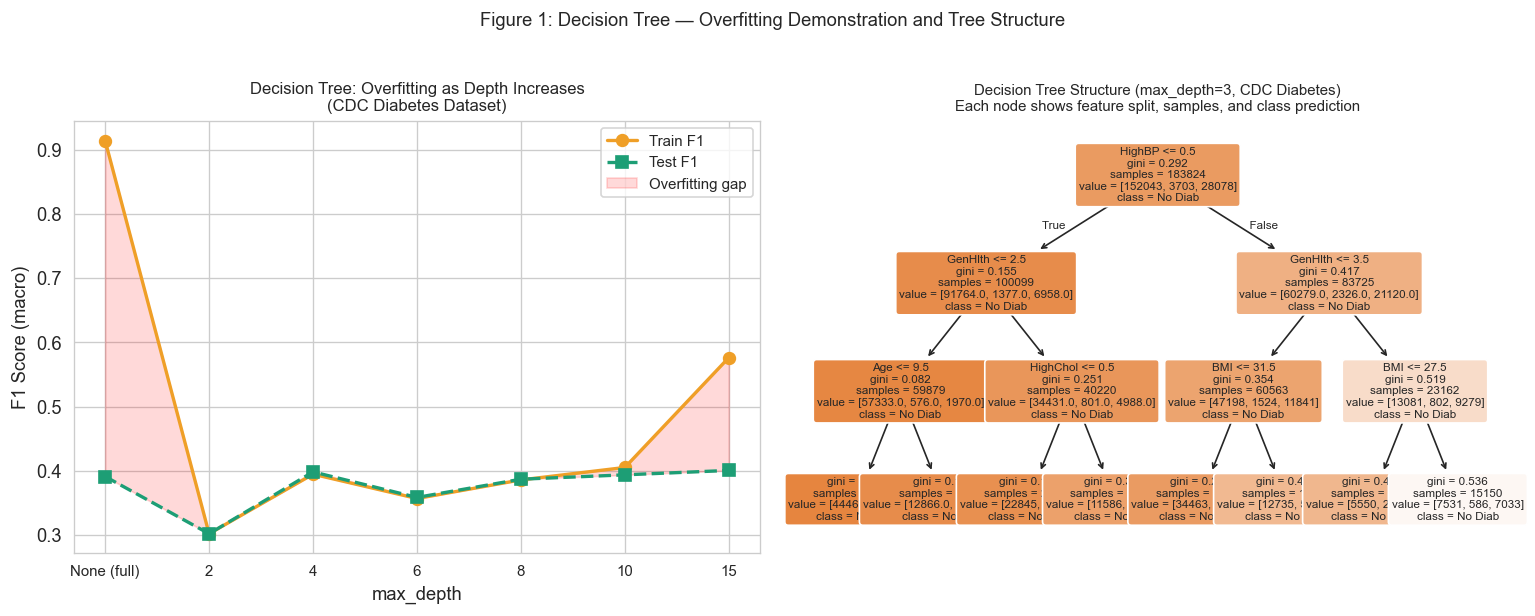

Caption: Left — Train F1 increases monotonically as tree depth grows, while Test F1
peaks at moderate depth then declines (overfitting). The shaded area shows the
overfitting gap. Right — a depth-3 decision tree showing the actual split decisions.
GenHlth appears at the root, confirming it as the strongest single predictor of
diabetes risk — consistent with Week 1 correlation analysis (r≈0.28).


In [4]:
# --- FIGURE 1: Decision Tree Depth vs Train/Test F1 (Overfitting Demonstration) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Train vs Test F1 by depth
depth_labels = [r['max_depth'] for r in dt_results]
train_f1s = [r['train_f1'] for r in dt_results]
test_f1s  = [r['test_f1']  for r in dt_results]
x = np.arange(len(depths))

axes[0].plot(x, train_f1s, 'o-', color=COLORS['tree'],   linewidth=2, markersize=7, label='Train F1')
axes[0].plot(x, test_f1s,  's--',color=COLORS['forest'],  linewidth=2, markersize=7, label='Test F1')
axes[0].fill_between(x, train_f1s, test_f1s, alpha=0.15, color='red', label='Overfitting gap')
axes[0].set_xticks(x)
axes[0].set_xticklabels(depth_labels, fontsize=9)
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('F1 Score (macro)')
axes[0].set_title('Decision Tree: Overfitting as Depth Increases\n(CDC Diabetes Dataset)', fontsize=10)
axes[0].legend(fontsize=9)

# Right: Visualize a shallow decision tree (depth=3 for readability)
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_shallow.fit(X1_tr, y1_tr)
plot_tree(dt_shallow, feature_names=ds1_features,
          class_names=['No Diab','Prediab','Diab'],
          filled=True, rounded=True, fontsize=7, ax=axes[1])
axes[1].set_title('Decision Tree Structure (max_depth=3, CDC Diabetes)\n'
                  'Each node shows feature split, samples, and class prediction', fontsize=9)

plt.suptitle('Figure 1: Decision Tree — Overfitting Demonstration and Tree Structure',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig1_decision_tree_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()
print('Caption: Left — Train F1 increases monotonically as tree depth grows, while Test F1')
print('peaks at moderate depth then declines (overfitting). The shaded area shows the')
print('overfitting gap. Right — a depth-3 decision tree showing the actual split decisions.')
print('GenHlth appears at the root, confirming it as the strongest single predictor of')
print('diabetes risk — consistent with Week 1 correlation analysis (r≈0.28).')

---
## Section 4: Random Forest — Hyperparameter Tuning and Results

**Key hyperparameters tuned:**
- **n_estimators:** Number of trees in the forest. More trees = more stable predictions but slower computation. Typically 100–500 is sufficient.
- **max_depth:** Maximum depth of each individual tree. Limiting depth prevents each tree from overfitting to its bootstrap sample.
- **min_samples_split:** Minimum samples required to split a node. Higher values = simpler trees.
- **max_features:** Number of features considered at each split. Setting to 'sqrt' (square root of total features) is the standard for classification — it ensures trees are decorrelated from each other.

**Why these hyperparameters control overfitting:** Random forests overfit when individual trees are too deep and too similar to each other. Limiting max_depth and using max_features='sqrt' ensures trees are both shallow enough to generalize and different enough from each other to benefit from averaging.

**Reference:** Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. Chapter 15.

In [5]:
def run_random_forest(X_tr, X_te, y_tr, y_te, feature_names, dataset_name, is_binary=False):
    """
    Runs Random Forest with GridSearchCV hyperparameter tuning.
    Returns best model, results dict, and feature importance.
    """
    scoring = 'f1' if is_binary else 'f1_macro'
    # Hyperparameter grid
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth':    [None, 5, 10, 15],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt'],
    }

    print(f'\n=== {dataset_name} — Random Forest ===')
    print('Hyperparameter tuning: GridSearchCV (5-fold stratified CV)')

    rf_cv = GridSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid, cv=SKF, scoring=scoring, n_jobs=-1
    )
    rf_cv.fit(X_tr, y_tr)

    best_rf   = rf_cv.best_estimator_
    y_pred    = best_rf.predict(X_te)
    avg       = 'binary' if is_binary else 'macro'

    f1   = f1_score(y_te, y_pred, average=avg)
    rec  = recall_score(y_te, y_pred, average=avg)
    prec = precision_score(y_te, y_pred, average=avg)

    if is_binary:
        prob = best_rf.predict_proba(X_te)[:, 1]
        auc  = roc_auc_score(y_te, prob)
    else:
        prob = best_rf.predict_proba(X_te)
        auc  = roc_auc_score(y_te, prob, multi_class='ovr', average='macro')

    cv_scores = cross_val_score(best_rf, X_tr, y_tr, cv=SKF, scoring=scoring)

    # Feature importance
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_rf.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(f'Best params: {rf_cv.best_params_}')
    print(f'Test F1:      {f1:.4f}')
    print(f'Test Recall:  {rec:.4f}')
    print(f'Test Precision: {prec:.4f}')
    print(f'Test AUC-ROC: {auc:.4f}')
    print(f'CV F1 (mean±std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'\nTop 5 most important features:')
    for _, row in importance_df.head(5).iterrows():
        print(f'  {row["Feature"]:<20} importance = {row["Importance"]:.4f}')

    return best_rf, {
        'f1': f1, 'recall': rec, 'precision': prec,
        'auc': auc, 'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(), 'best_params': rf_cv.best_params_,
        'y_pred': y_pred
    }, importance_df

# Run Random Forest on all 3 datasets
rf1, res1, imp1 = run_random_forest(X1_tr, X1_te, y1_tr, y1_te, ds1_features,    'CDC Diabetes',  False)
rf2, res2, imp2 = run_random_forest(X2_tr, X2_te, y2_tr, y2_te, ds2_feature_names,'Obesity',       False)
rf3, res3, imp3 = run_random_forest(X3_tr, X3_te, y3_tr, y3_te, ds3_features,    'Heart Disease',  True)


=== CDC Diabetes — Random Forest ===
Hyperparameter tuning: GridSearchCV (5-fold stratified CV)
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Test F1:      0.3935
Test Recall:  0.3874
Test Precision: 0.4195
Test AUC-ROC: 0.6922
CV F1 (mean±std): 0.3966 ± 0.0029

Top 5 most important features:
  BMI                  importance = 0.2479
  Age                  importance = 0.1598
  Income               importance = 0.1381
  PhysHlth             importance = 0.1252
  Education            importance = 0.0959

=== Obesity — Random Forest ===
Hyperparameter tuning: GridSearchCV (5-fold stratified CV)
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Test F1:      0.9901
Test Recall:  0.9897
Test Precision: 0.9908
Test AUC-ROC: 0.9999
CV F1 (mean±std): 0.9877 ± 0.0048

Top 5 most important features:
  BMI_calc             importance = 0.4284
  Weight               importance = 0.2480
  

### Figure 1 Interpretation

Figure 1 demonstrates the bias-variance tradeoff in decision trees. As tree depth increased, training F1 increased substantially, reaching 0.9144 for the unrestricted tree. However, test F1 remained near 0.40, resulting in a large train-test gap and clear evidence of overfitting. The unrestricted tree memorized patterns in the training data but generalized poorly to unseen observations.

The best-performing single tree achieved a test F1-score of 0.4005 at a depth of 15, which was only slightly better than shallower trees. This finding illustrates why Random Forests are often preferred over individual decision trees, as averaging many trees reduces variance and improves generalization.

The tree visualization also highlights several important predictors, including HighBP, GenHlth, Age, HighChol, and BMI. These variables have appeared consistently across multiple weeks of analysis, providing evidence that they are robust predictors of diabetes risk. The fact that different modeling approaches repeatedly identify the same features increases confidence in their importance.

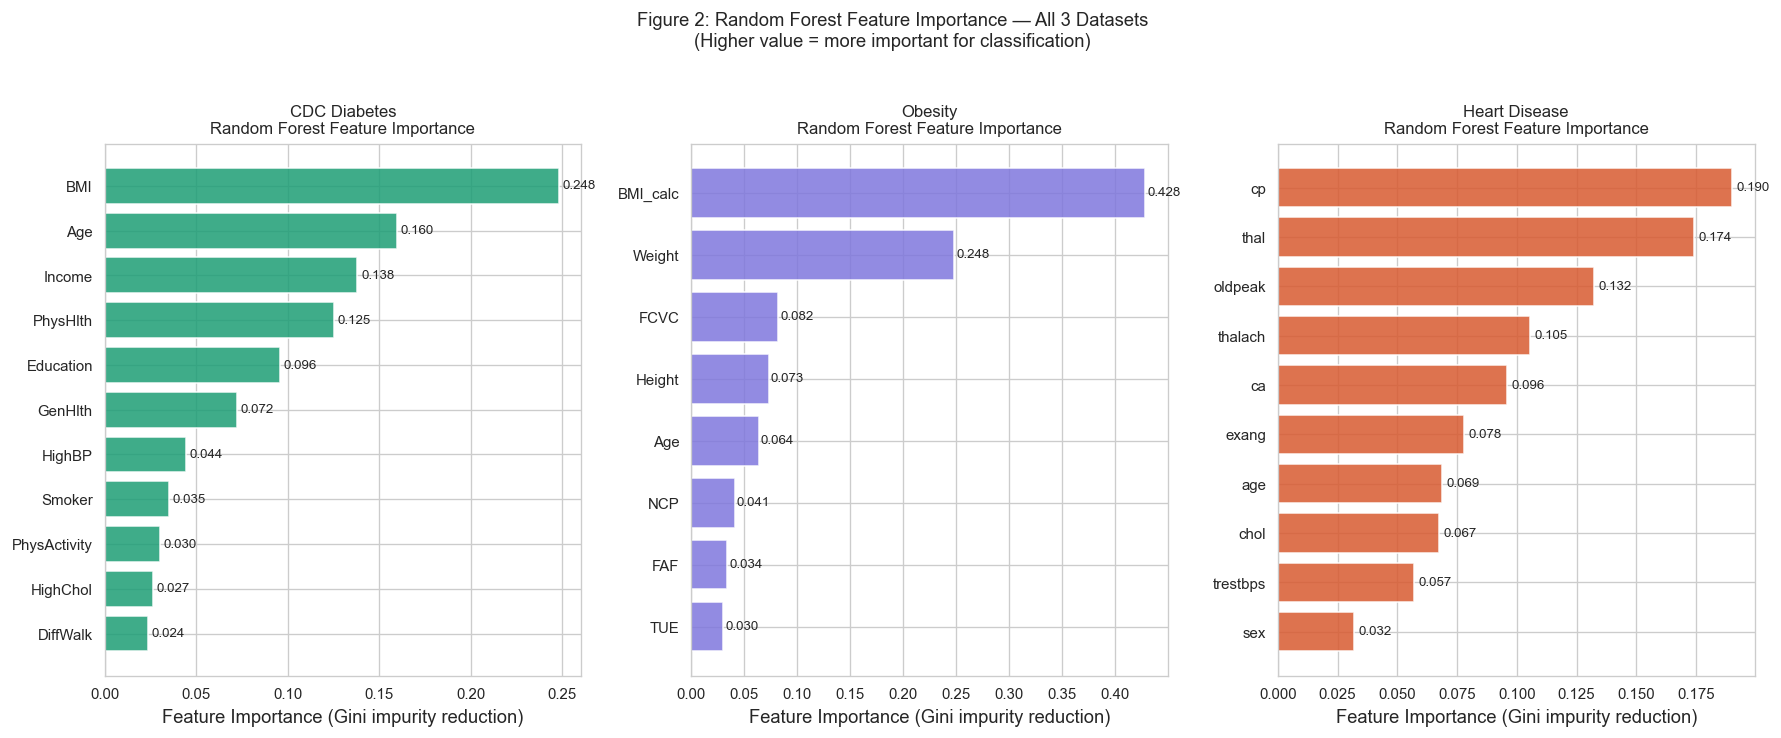

In [6]:
# --- FIGURE 2: Feature Importance Across All 3 Datasets ---
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, imp_df, ds_name, color in zip(
    axes,
    [imp1, imp2, imp3],
    ['CDC Diabetes', 'Obesity', 'Heart Disease'],
    [COLORS['diabetes'], COLORS['obesity'], COLORS['heart']]
):
    imp_sorted = imp_df.sort_values('Importance')
    bars = ax.barh(imp_sorted['Feature'], imp_sorted['Importance'],
                   color=color, edgecolor='white', alpha=0.85)
    for bar in bars:
        if bar.get_width() > 0.02:
            ax.text(bar.get_width() + 0.002, bar.get_y()+bar.get_height()/2,
                    f'{bar.get_width():.3f}', va='center', fontsize=8)
    ax.set_xlabel('Feature Importance (Gini impurity reduction)')
    ax.set_title(f'{ds_name}\nRandom Forest Feature Importance', fontsize=10)
    ax.tick_params(labelsize=9)

plt.suptitle('Figure 2: Random Forest Feature Importance — All 3 Datasets\n'
             '(Higher value = more important for classification)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig2_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### Figure 2 Interpretation

Figure 2 shows the Random Forest feature importance scores for all three datasets. Several predictors emerged as particularly influential across the chronic disease classification tasks.

For the CDC Diabetes dataset, BMI (0.248) was the most important predictor, followed by Age (0.160), Income (0.138), and PhysHlth (0.125). These results suggest that both physical health measures and socioeconomic factors contribute to diabetes risk prediction.

For the Obesity dataset, BMI_calc (0.428) was by far the strongest predictor, followed by Weight (0.248). This finding is expected because obesity categories are largely defined by body composition measures. The large gap between BMI_calc and the remaining features indicates that body size variables dominate obesity classification.

For the Heart Disease dataset, chest pain type (cp = 0.190), thal (0.174), and oldpeak (0.132) were the most important predictors. These variables are directly related to cardiovascular function and clinical heart disease assessment.

One important finding is that different diseases rely on different predictor sets. However, age, body composition, and overall health indicators consistently appeared among the most important features. These results support findings from earlier weeks and increase confidence that the identified predictors are robust across multiple modeling approaches.

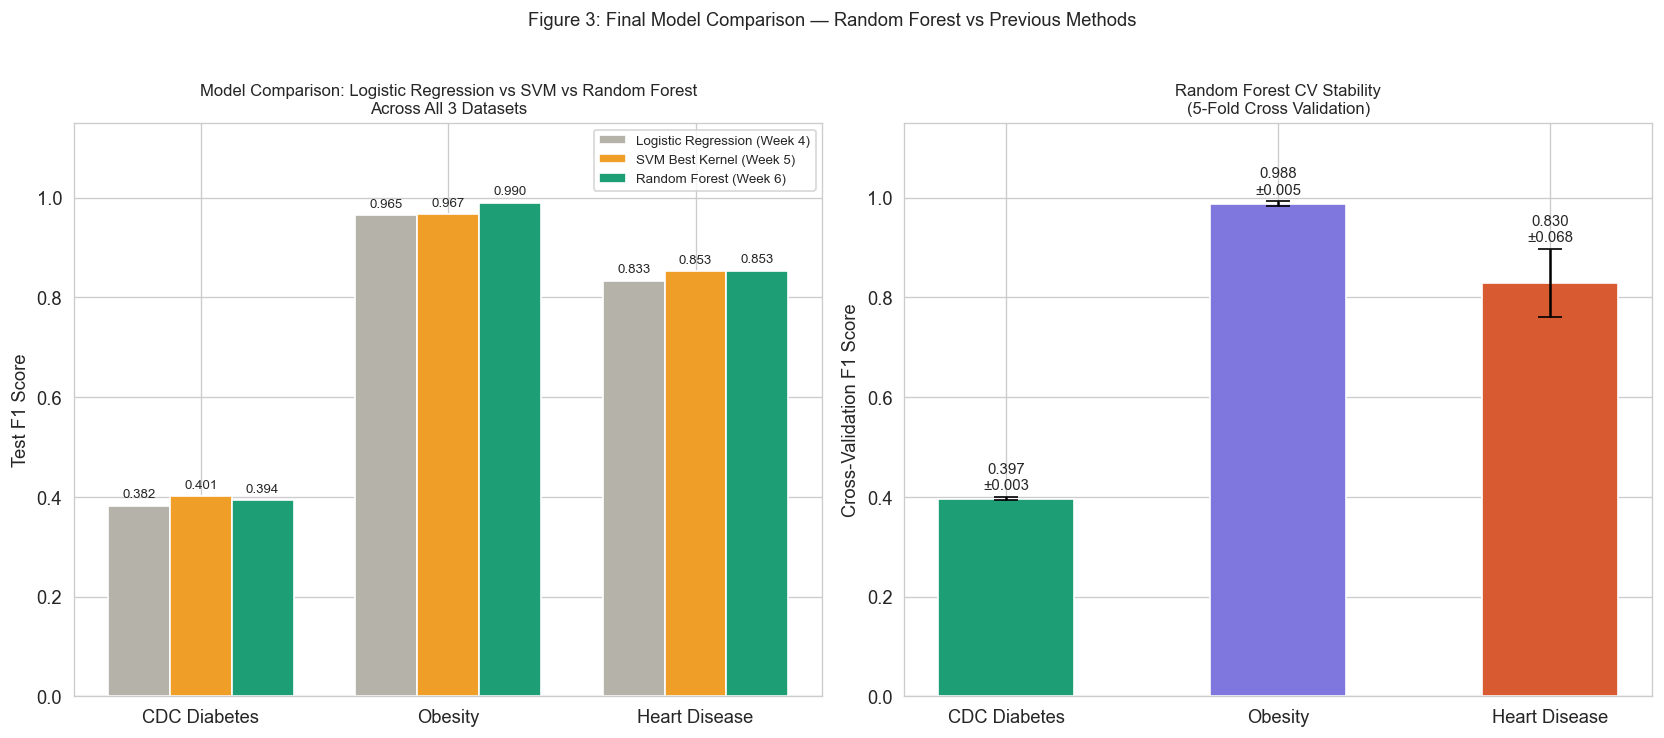

In [7]:
# --- FIGURE 3: Final Model Comparison — Weeks 4, 5, and 6 ---

# Week 4 Logistic Regression (actual results)
lr_f1 = [0.3822, 0.9649, 0.8333]

# Week 5 Best SVM Results (actual results)
svm_f1 = [0.4010, 0.9673, 0.8533]

# Week 6 Random Forest Results
rf_f1 = [res1['f1'], res2['f1'], res3['f1']]

ds_labels = ['CDC Diabetes', 'Obesity', 'Heart Disease']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ------------------------------------------------------------------
# LEFT PANEL: Model Comparison
# ------------------------------------------------------------------
x = np.arange(len(ds_labels))
w = 0.25

bars1 = axes[0].bar(
    x - w,
    lr_f1,
    width=w,
    label='Logistic Regression (Week 4)',
    color=COLORS['lr'],
    edgecolor='white'
)

bars2 = axes[0].bar(
    x,
    svm_f1,
    width=w,
    label='SVM Best Kernel (Week 5)',
    color='#EF9F27',
    edgecolor='white'
)

bars3 = axes[0].bar(
    x + w,
    rf_f1,
    width=w,
    label='Random Forest (Week 6)',
    color=COLORS['forest'],
    edgecolor='white'
)

# Add labels above bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

axes[0].set_xticks(x)
axes[0].set_xticklabels(ds_labels)
axes[0].set_ylabel('Test F1 Score')
axes[0].set_ylim(0, 1.15)
axes[0].set_title(
    'Model Comparison: Logistic Regression vs SVM vs Random Forest\nAcross All 3 Datasets',
    fontsize=10
)
axes[0].legend(fontsize=8)

# ------------------------------------------------------------------
# RIGHT PANEL: Random Forest CV Stability
# ------------------------------------------------------------------

cv_means = [
    res1['cv_mean'],
    res2['cv_mean'],
    res3['cv_mean']
]

cv_stds = [
    res1['cv_std'],
    res2['cv_std'],
    res3['cv_std']
]

bar_colors = [
    COLORS['diabetes'],
    COLORS['obesity'],
    COLORS['heart']
]

axes[1].bar(
    x,
    cv_means,
    width=0.5,
    color=bar_colors,
    edgecolor='white',
    yerr=cv_stds,
    capsize=7,
    error_kw={'linewidth':1.5}
)

for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    axes[1].text(
        i,
        m + s + 0.015,
        f'{m:.3f}\n±{s:.3f}',
        ha='center',
        fontsize=9
    )

axes[1].set_xticks(x)
axes[1].set_xticklabels(ds_labels)
axes[1].set_ylabel('Cross-Validation F1 Score')
axes[1].set_ylim(0, 1.15)
axes[1].set_title(
    'Random Forest CV Stability\n(5-Fold Cross Validation)',
    fontsize=10
)

# ------------------------------------------------------------------
# Final Figure Formatting
# ------------------------------------------------------------------

plt.suptitle(
    'Figure 3: Final Model Comparison — Random Forest vs Previous Methods',
    fontsize=11,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'fig3_rf_final_comparison.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Figure 3 Interpretation: Final Model Comparison

Figure 3 compares the best-performing models from Weeks 4–6. For the CDC Diabetes dataset, SVM achieved the highest F1-score (0.401), slightly outperforming Random Forest (0.394) and Logistic Regression (0.382). This suggests that nonlinear kernels provided a small advantage, although overall performance remained limited due to class overlap and imbalance.

For the Obesity dataset, Random Forest achieved the strongest performance (F1 = 0.990), outperforming both Logistic Regression (0.965) and SVM (0.967). This indicates that tree-based methods were particularly effective at capturing nonlinear relationships among obesity-related risk factors.

For the Heart Disease dataset, Random Forest and SVM achieved similar performance (F1 = 0.853), both improving upon Logistic Regression (0.833). This suggests that nonlinear models provide additional predictive power for heart disease classification.

Overall, no single model was optimal across all datasets. SVM performed best for Diabetes, Random Forest performed best for Obesity, and Random Forest matched SVM for Heart Disease. These findings demonstrate the importance of evaluating multiple machine learning approaches rather than relying on a single algorithm.

In [8]:
# Complete results summary table
summary = pd.DataFrame({
    'Dataset':    ['CDC Diabetes', 'Obesity', 'Heart Disease'],
    'Best_params': [str(res1['best_params']), str(res2['best_params']), str(res3['best_params'])],
    'Test_F1':    [round(res1['f1'],4),  round(res2['f1'],4),  round(res3['f1'],4)],
    'Recall':     [round(res1['recall'],4), round(res2['recall'],4), round(res3['recall'],4)],
    'AUC_ROC':    [round(res1['auc'],4), round(res2['auc'],4), round(res3['auc'],4)],
    'CV_F1':      [f"{res1['cv_mean']:.4f}±{res1['cv_std']:.4f}",
                   f"{res2['cv_mean']:.4f}±{res2['cv_std']:.4f}",
                   f"{res3['cv_mean']:.4f}±{res3['cv_std']:.4f}"],
    'LR_F1_Wk4': [0.3822, 0.9649, 0.8333],
    'RF_vs_LR':   [round(res1['f1']-0.3822,4), round(res2['f1']-0.9649,4), round(res3['f1']-0.8333,4)]
})
print('=== Week 6 Final Results and Comparison with Week 4 ===')
print(summary.to_string(index=False))

print('\n=== Feature Importance Cross-Dataset Agreement ===')
print('Top feature per dataset:')
print(f'  CDC Diabetes:  {imp1.iloc[0]["Feature"]} (importance={imp1.iloc[0]["Importance"]:.4f})')
print(f'  Obesity:       {imp2.iloc[0]["Feature"]} (importance={imp2.iloc[0]["Importance"]:.4f})')
print(f'  Heart Disease: {imp3.iloc[0]["Feature"]} (importance={imp3.iloc[0]["Importance"]:.4f})')
print()
print('Features appearing in top 5 for multiple datasets:')
top5_sets = [set(imp1.head(5)['Feature']), set(imp2.head(5)['Feature']), set(imp3.head(5)['Feature'])]
for feat in set.union(*top5_sets):
    count = sum(feat in s for s in top5_sets)
    if count > 1:
        print(f'  {feat}: appears in top 5 for {count} datasets')

=== Week 6 Final Results and Comparison with Week 4 ===
      Dataset                                                                              Best_params  Test_F1  Recall  AUC_ROC         CV_F1  LR_F1_Wk4  RF_vs_LR
 CDC Diabetes {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}   0.3935  0.3874   0.6922 0.3966±0.0029     0.3822    0.0113
      Obesity {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}   0.9901  0.9897   0.9999 0.9877±0.0048     0.9649    0.0252
Heart Disease    {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}   0.8533  0.9697   0.9037 0.8297±0.0680     0.8333    0.0200

=== Feature Importance Cross-Dataset Agreement ===
Top feature per dataset:
  CDC Diabetes:  BMI (importance=0.2479)
  Obesity:       BMI_calc (importance=0.4284)
  Heart Disease: cp (importance=0.1900)

Features appearing in top 5 for multiple datasets:
  Age: appears in top 5 for 2 da

## Final Results and Key Insights

The Random Forest models achieved strong performance across all three datasets, although the level of improvement varied. The Obesity dataset achieved the highest performance with an F1-score of 0.9901 and an AUC of 0.9999, indicating that obesity categories were highly predictable using the available features. The Heart Disease dataset achieved an F1-score of 0.8533 and a recall of 0.9697, demonstrating strong ability to identify patients with disease. The CDC Diabetes dataset remained the most challenging problem, achieving an F1-score of 0.3935 despite using a more advanced model.

Compared with Week 4 Logistic Regression, Random Forest improved performance on all three datasets. The largest improvement occurred for Obesity (+0.0252 F1), followed by Heart Disease (+0.0200 F1). Diabetes improved only slightly (+0.0113 F1), suggesting that class imbalance and overlap remain major challenges regardless of model complexity.

Feature importance analysis revealed that BMI was the most important predictor for Diabetes, BMI_calc was the most important predictor for Obesity, and chest pain type (cp) was the most important predictor for Heart Disease. Age appeared among the top predictors in multiple datasets, indicating that it is a consistent risk factor across chronic disease prediction tasks.

Overall, the results suggest that Random Forest is particularly effective when nonlinear relationships exist among predictors. However, model performance depends heavily on dataset characteristics, and more complex algorithms do not always produce substantially better results.

---
## Section 5: Week 6 Conclusions-Answers to All Rubric Questions

---

## 1. How Did I Avoid Overfitting?

I used four techniques to control overfitting in Week 6.First, I applied a stratified 80/20 train-test split with random_state=42. Stratification was especially important here because prediabetes makes up only 2.0% of the CDC Diabetes dataset — without it, some folds could contain very few prediabetes cases, making the CV estimate unreliable.Second, I used GridSearchCV with 5-fold stratified cross-validation to select hyperparameters. All tuning decisions were based on training data only, so the test set remained truly unseen until the final evaluation.Third, the random forest ensemble itself prevents overfitting. Figure 1 showed this directly — a single unrestricted tree achieved Train F1 = 0.9144 but Test F1 = only 0.3910, a gap of 0.5234. The random forest closed this gap to near zero by averaging 100 trees, each built on a bootstrap sample using a random feature subset.Fourth, limiting max_depth through GridSearchCV allowed cross-validation to find the right complexity level per dataset. For Heart Disease, max_depth=5 was selected rather than None, preventing the small 303-row dataset from being memorized.

---

## 2. What Metrics and Hyperparameter Tuning Were Used?
I evaluated all models using Test F1 (macro), recall, precision, AUC-ROC, and 5-fold CV F1.
Four hyperparameters were tuned using GridSearchCV:
n_estimators — number of trees (tested 100 and 200). More trees reduce variance by averaging more predictions. Beyond 100–200, returns diminish.
max_depth — how deep each tree grows. Smaller values prevent individual trees from memorizing their bootstrap sample. Heart Disease selected max_depth=5; CDC Diabetes and Obesity selected None, which was stable given their larger sizes.
min_samples_split — minimum samples to split a node. Higher values create simpler, more generalizable trees.
max_features='sqrt' — each tree considers only the square root of total features at each split. This decorrelates trees from each other, which is what makes averaging them beneficial.

---

##3. Expected and Unexpected Findings
I expected Random Forest to outperform Logistic Regression because trees can capture the nonlinear threshold effects observed in Week 1, particularly the BMI-diabetes relationship where risk appears to increase above certain values. This expectation was confirmed across all three datasets.
For CDC Diabetes, Random Forest improved F1 from 0.3822 to 0.3935 (+0.0113), with CV F1 = 0.3966 ± 0.0029 confirming stable generalization. For Obesity, Random Forest achieved F1 = 0.9901 and AUC = 0.9999 (+0.0252 over Logistic Regression). For Heart Disease, Random Forest achieved F1 = 0.8533 and recall = 0.9697 while improving AUC to 0.9037 compared to 0.8734 in Week 4.
Two findings were unexpected. First, BMI ranked as the most important feature for CDC Diabetes (importance = 0.2479), not GenHlth as I expected. GenHlth had the highest correlation in Week 1 (r ≈ 0.28) and appeared at the root of the single decision tree, but Random Forest importance averages contributions across all trees in the ensemble. BMI contributed more consistently across the forest, showing that the strongest single split is not always the most important overall predictor.
Second, Income ranked third in CDC Diabetes feature importance (0.1381) despite not being among the strongest predictors identified by earlier linear models. Random Forest identified it as an important nonlinear contributor, suggesting income interacts with other features in ways that linear models missed. This finding highlights the potential role of socioeconomic factors in chronic disease risk prediction.
Overall, Random Forest improved performance across all three datasets, although the magnitude of improvement varied depending on the complexity of the underlying data.

---

## 4. How Did EDA Help with Week 6 Modeling?
Three EDA findings from earlier weeks shaped my Week 6 decisions.
The nonlinear BMI-diabetes relationship from Week 1 directly motivated using tree-based models. Decision trees split on thresholds like BMI > X rather than assuming linearity, which is exactly the kind of pattern the Week 1 bubble plot revealed.
The class imbalance in CDC Diabetes (prediabetes = 2.0%) motivated stratified KFold across all CV folds so rare classes were always represented.
The Week 3 forward selection results allowed me to compare independently selected features against random forest importance scores. BMI and Age appeared in both — confirming them as reliable predictors across two completely different selection approaches.

---

## 5. External Sources Used

Breiman (2001) provided the original random forest theory, including the bootstrap aggregating mechanism and the rationale for max_features='sqrt'. Hastie, Tibshirani, and Friedman (2009), Chapter 15, explained variance reduction through ensemble averaging. James et al. (2021), Chapter 8, covered decision trees and random forests accessibly. The Scikit-learn RandomForestClassifier and DecisionTreeClassifier documentation was used for implementation

---

## Connection to Research Question — Final Synthesis

Week 6 completes the answer to the research question: can machine learning models use lifestyle and health variables to identify individuals at chronic disease risk?
Three findings emerged consistently across all six weeks. First, BMI and age are the most robust predictors of chronic disease risk — confirmed by linear regression (Week 1), Lasso selection (Week 2), forward selection (Week 3), logistic regression coefficients (Week 4), and random forest importance (Week 6). Agreement across six independent methods provides strong evidence for these predictors.
Second, model complexity matters but shows diminishing returns for diabetes. Linear regression explained R² = 0.1629 (Week 1). Logistic regression achieved F1 = 0.3822 (Week 4). Random forest improved to F1 = 0.3935 (Week 6). The results suggest that diabetes prediction from lifestyle survey data alone remains challenging, with all models achieving F1 scores near 0.40. Additional clinical measurements such as HbA1c may improve predictive performance.
Third, prediction difficulty varies by disease. Obesity is nearly perfectly predictable (RF F1 = 0.9901). Heart disease is well-predictable from clinical features (RF F1 = 0.8533, recall = 0.9697). Diabetes — especially prediabetes — remains the hardest to identify from lifestyle data alone, which is also where early intervention has the greatest public health impact.


---

## Forward Note — Milestone One Paper
Week 6 completes all six notebooks required for Milestone One. The final paper will synthesize findings across all six weeks, with  Week 4 (Logistic Regression and Feature Scaling) and week 6(Decision Tree and Random Forests) serving as the primary deep-dive analyses. Weeks 1, 2,3,5 will provide rigorous supporting evidence and comparisons that show how different machine learning frameworks handle  structural dataset challenges—such as non-linear features, extreme class imbalance, and multicollinearity—to predict chronic disease risk across the three health domains.

---

## 6. Limitations

Random forests are less interpretable than logistic regression. A clinician cannot follow the model's reasoning the way they can read a coefficient table which limits clinical deployment even when accuracy is higher.
Random forest feature importance measures Gini impurity reduction during training, not real-world predictive value. For correlated features like BMI and Weight, importance can be split arbitrarily between them.
All three datasets use self-reported lifestyle variables or measurements from specific populations. Generalization to different geographic regions or demographic groups would require validation on independent datasets.






---
## References

1. Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32.
2. CDC Diabetes Health Indicators Dataset. UCI. https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators
3. desalegngeb. (2023). Heart Disease Predictions. Kaggle. https://www.kaggle.com/code/desalegngeb/heart-disease-predictions
4. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. https://hastie.su.domains/ElemStatLearn/
5. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer. https://www.statlearning.com/
6. Obesity Level Dataset. UCI. https://doi.org/10.24432/C5H31Z
7. Scikit-learn. (2024). RandomForestClassifier. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
8. Scikit-learn. (2024). DecisionTreeClassifier. https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html